# Tiền xử lý dữ liệu 

## Mục tiêu

Sau khi hoàn thành bài thực hành này, học viên có thể:

-   Xử lý dữ liệu bị thiếu
-   Hiệu chỉnh lại kiểu dữ liệu
-   Chuẩn hóa dữ liệu

<h2>Mục đích của việc tiền xử lý dữ liệu  là gì?</h2>

Tiền xử lý dữ liệu quá trình chuyển đổi dữ liệu từ định dạng ban đầu sang định dạng có thể tốt hơn cho việc phân tích.

<h3>Import data</h3>

Trong chương này chúng ta sẽ sử dụng bộ dataset: `Automobile Data Set` 

<h4>Import pandas</h4> 


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

<h2>Đọc dữ liệu từ URL và thêm tên cột tương ứng.</h2>


In [6]:
# Url dữ liệu
filename = "L06_datasets/automotive_data/data.csv"

Tạo một list chứa tên cột tương ứng và theo thứ tự

In [7]:
headers = ["symboling","normalized-losses","make","fuel-type","aspiration", "num-of-doors","body-style",
         "drive-wheels","engine-location","wheel-base", "length","width","height","curb-weight","engine-type",
         "num-of-cylinders", "engine-size","fuel-system","bore","stroke","compression-ratio","horsepower",
         "peak-rpm","city-mpg","highway-mpg","price"]

Chúng ta sẽ sử dụng hàm <b>read_csv()</b> trong pandas để đọc dữ liệu từ website. 

Đặt tham số "names" = "headers" vừa được tạo.


In [8]:
df = pd.read_csv(filename, names = headers)

Show 5 hàng đầu của dataframe

In [9]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


Như chúng ta có thể thấy, một số dấu hỏi đã xuất hiện trong dataframe; đó là những giá trị còn thiếu có thể cản trở việc phân tích.

<div>Làm thế nào chúng ta có thể tìm và xử lý dữ liệu bị thiếu?</div> 


**Các bước xử lý dữ liệu bị thiếu**

<ol>
    <li>Xác định dữ liệu bị thiếu</li>
    <li>Xử lý dữ liệu bị thiếu</li>
    <li>Điều chỉnh dữ liệu theo định dạng chuẩn</li>
</ol>


<h2 id="identify_handle_missing_values">Xác định và xử lý dữ liệu bị thiếu</h2>

<h3 id="identify_missing_values">Xác định dữ liệu bị thiếu</h3>
<h4>biến đổi "?" thành NaN</h4>

Trọng bộ dữ liệu về ô tô, dữ liệu bị thiếu được nhận biết bằng dấu "?". Chúng ta có thể biến đổi "?" thành NaN (Not a Number). NaN là giá trị bị thiếu mặc định trong python.

Chúng ta có thể sử dụng hàm như sau: 

 <pre>.replace(A, B, inplace = True) </pre>
Để thay thế giá trị A bằng giá trị B


In [10]:
import numpy as np

# replace "?" to NaN
df.replace("?", np.nan, inplace = True)
df.head(5)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


<h4>Đánh giá dữ liệu bị thiếu:</h4>

Sau khi dữ liệu bị thiếu đã được biến đổi về format chuẩn của Pandas dataframe, có 2 hàm hữu ích thường được sử dụng để xác định dữ liệu bị thiếu:

<ol>
    <li><b>.isnull()</b></li>
    <li><b>.notnull()</b></li>
</ol>

Kết quả trả về sẽ là True/False nếu dữ liệu của dataframe thoả mãn điều kiện của hàm.


In [11]:
missing_data = df.isnull()
missing_data.head(5)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


"True" là dữ liệu bị thiếu, còn "False" là dữ liệu không bị thiếu:


<h4>Xác định số lượng dữ liệu bị thiếu ở các cột</h4>


In [12]:
for column in missing_data.columns.values.tolist():
    print(column)
    print (missing_data[column].value_counts())
    print("")    

symboling
symboling
False    205
Name: count, dtype: int64

normalized-losses
normalized-losses
False    164
True      41
Name: count, dtype: int64

make
make
False    205
Name: count, dtype: int64

fuel-type
fuel-type
False    205
Name: count, dtype: int64

aspiration
aspiration
False    205
Name: count, dtype: int64

num-of-doors
num-of-doors
False    203
True       2
Name: count, dtype: int64

body-style
body-style
False    205
Name: count, dtype: int64

drive-wheels
drive-wheels
False    205
Name: count, dtype: int64

engine-location
engine-location
False    205
Name: count, dtype: int64

wheel-base
wheel-base
False    205
Name: count, dtype: int64

length
length
False    205
Name: count, dtype: int64

width
width
False    205
Name: count, dtype: int64

height
height
False    205
Name: count, dtype: int64

curb-weight
curb-weight
False    205
Name: count, dtype: int64

engine-type
engine-type
False    205
Name: count, dtype: int64

num-of-cylinders
num-of-cylinders
False    205
Nam

Kết quả cho ta thấy, mỗi cột có 205 dòng, và 7 cột bị thiếu dữ liệu:

<ol>
    <li>"normalized-losses": 41 giá trị</li>
    <li>"num-of-doors": 2 giá trị</li>
    <li>"bore": 4 giá trị</li>
    <li>"stroke" : 4 giá trị</li>
    <li>"horsepower": 2 giá trị</li>
    <li>"peak-rpm": 2 giá trị</li>
    <li>"price": 4 giá trị</li>
</ol>


<h3 id="deal_missing_values">Xử lý dữ liệu bị thiếu </h3>
<b>Làm sao để xử lý dữ liệu bị thiếu?</b>

<ol>
    <li>Loại bỏ giá trị bị thiếu<br>
        a. Loại bỏ tất cả các hàng<br>
        b. Loại bỏ tất cả các cột
    </li>
    <li>Thay thế nó<br>
        a. Thay thế dữ liệu bị thiếu bằng giá trị trung bình<br>
        b. Thay thế dữ liệu bị thiếu bằng tần suất xuất hiện<br>
        c. Thay thế dữ liệu bị thiếu bằng một vài hàm khác
    </li>
</ol>


Chúng ta có thể áp dụng các phương pháp khác nhau cho từng cột dữ liệu:

<b>Thay thế dữ liệu bị thiếu bằng giá trị trung bình:</b>

<ul>
    <li>"normalized-losses": 41 giá trị, thay thế dữ liệu bị thiếu bằng giá trị trung bình</li>
    <li>"stroke": 4 giá trị, thay thế dữ liệu bị thiếu bằng giá trị trung bình</li>
    <li>"bore": 4 giá trị, thay thế dữ liệu bị thiếu bằng giá trị trung bình</li>
    <li>"horsepower": 2 giá trị, thay thế dữ liệu bị thiếu bằng giá trị trung bình</li>
    <li>"peak-rpm": 2 giá trị, thay thế dữ liệu bị thiếu bằng giá trị trung bình</li>
</ul>

<b>Replace by frequency:</b>

<ul>
    <li>"num-of-doors": 2 giá trị, thay thế giá trị = "four". 
        <ul>
            <li>Lý do: 84% xe sedans thì có 4 cửa, và có xác suất xảy ra cao nhất.</li>
        </ul>
    </li>
</ul>

<b>Loại bỏ giá trị bị thiếu:</b>

<ul>
    <li>"price": 4 giá trị, cách đơn giản nhất là loại bỏ nó
        <ul>
            <li>Lý do: Cột Price là cột dữ liệu chúng ta cần xây dựng mô hình để dự đoán nó, dữ liệu sai lệch có thể khiến mô hình hoạt động không hiệu quả</li>
        </ul>
    </li>
</ul>


<h4>Tính toán giá trị trung bình của cột: </h4>


In [13]:
avg_norm_loss = df["normalized-losses"].astype("float").mean(axis=0)
print("Giá trị trung bình của cột normalized-losses:", avg_norm_loss)

Giá trị trung bình của cột normalized-losses: 122.0


<h4>Thay thế "NaN" bằng giá trị trung bình cho cột "normalized-losses"</h4>


In [14]:
df["normalized-losses"].replace(np.nan, avg_norm_loss, inplace=True)

<h4>Tính toán giá trị trung bình của cột 'bore'</h4>


In [15]:
avg_bore=df['bore'].astype('float').mean(axis=0)
print("Giá trị trung bình của cột bore:", avg_bore)

Giá trị trung bình của cột bore: 3.3297512437810943


<h4>Thay thế "NaN" bằng giá trị trung bình</h4>


In [16]:
df["bore"].replace(np.nan, avg_bore, inplace=True)

<h1> Bài tập 1: </h1>

Tham khảo ví dụ trên, thay thế "NaN" bằng giá trị trung bình cho các cột `stroke`, `horsepower`, `peak-rpm`





<h4>Cột stroke: </h4>

In [17]:
avg_stroke = df["stroke"].astype("float").mean(axis=0)
df["stroke"].replace(np.nan, avg_stroke, inplace=True)

<h4>Cột horsepower: </h4>

In [18]:
avg_hp = df["horsepower"].astype("float").mean(axis=0)
df["horsepower"].replace(np.nan, avg_hp, inplace=True)

<h4>Cột peak-rpm: </h4>

In [19]:
avg_peakrpm = df["peak-rpm"].astype("float").mean(axis=0)
df["peak-rpm"].replace(np.nan, avg_peakrpm, inplace=True)

<h4>Tìm số cửa xuất hiện nhiều nhất trong tập datasets: </h4>

In [20]:
df['num-of-doors'].value_counts()

num-of-doors
four    114
two      89
Name: count, dtype: int64

Kết quả cho ta thấy xe hơi 4 chứa chiếm đa số trong tập dữ liệu này. Để tự động xuất ra kết quả số cửa xuất hiện nhiều nhất, chúng ta có thể sử dụng hàm `.idxmax()`

In [21]:
df['num-of-doors'].value_counts().idxmax()

'four'

<h4>Thay thế dữ liệu bị thiếu ở cột num-of-doors bằng giá trị xuất hiện nhiều nhất: </h4>

In [22]:
# Thay thế NaN bằng giá trị xuất hiện nhiều nhất
df["num-of-doors"].replace(np.nan, "four", inplace=True)

<h4>Loại bỏ tất cả các hàng của mà không có dữ liệu price: </h4>

In [23]:
# Xoá dữ liệu bị thiếu
df.dropna(subset=["price"], axis=0, inplace=True)

# reset index sau khi xoá dữ liệu
df.reset_index(drop=True, inplace=True)

In [24]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,122.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,122.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


<b>Good!</b> Bây giờ chúng ta đã có một bộ dữ liệu mới không còn hiện tượng thiếu dữ liệu, so what is next?


<h3 id="correct_data_format">Hiệu chỉnh lại kiểu dữ liệu</h3>
<p>Bước cuối cùng trong quá trình tiền xử lý dữ liệu là đảm bảo tất cả cột dữ liệu theo đúng kiểu dữ liệu mong muốn (int, float, text...)</p>

Chúng ta có thể sử dụng 2 hàm sau:

<p><b>.dtype()</b> Kiểm tra kiểu dữ liệu hiện tại</p>
<p><b>.astype()</b> Thay đổi kiểu dữ liệu</p>


<h4>Liệt kê kiểu dữ liệu của tất cả các cột:</h4>


In [25]:
df.dtypes

symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                  object
stroke                object
compression-ratio    float64
horsepower            object
peak-rpm              object
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object

Chúng ta có thể thấy một vài cột không theo kiểu dữ liệu mong muốn. Các dữ liệu định lượng thường có type là 'float' hay là 'int', và dữ liệu định tính sang chuỗi thường có type là 'Object'. Chúng ta phải hiệu chỉnh các cột về kiểu dữ liệu hợp lý theo đúng bản chất của dữ liệu bằng hàm: `astype()` 

<h4>Điều chỉnh kiểu dữ liệu các cột về đúng format chuẩn</h4>


In [26]:
df[["bore", "stroke"]] = df[["bore", "stroke"]].astype("float")
df[["normalized-losses"]] = df[["normalized-losses"]].astype("int")
df[["price"]] = df[["price"]].astype("float")
df[["peak-rpm"]] = df[["peak-rpm"]].astype("float")

<h4>Liệt kê kiểu dữ liệu của tất cả các cột sau khi điều chỉnh:</h4>


In [27]:
df.dtypes

symboling              int64
normalized-losses      int64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower            object
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object

<b>Wonderful!</b>

Bây giờ chúng ta đã có một bộ dữ liệu mới theo đúng format và không bị thiếu dữ liệu!


<h2 id="data_standardization">Data Standardization</h2>
<p>
Dữ liệu thường được thu thập từ các nguồn khác nhau với các định dạng khác nhau
</p>
    
<b>What is Standardization?</b>
<p>Standardization là quá trình chuyển đổi dữ liệu sang một định dạng chung cho phép nhà nghiên cứu/phân tích thực hiện so sánh có ý nghĩa..
</p>

<b>Ví dụ</b>

<p>Biến đổi mpg sang L/100km:</p>
<p>Trong tập dữ liệu này, mức độ tiêu hao nhiên liệu của cột "city-mpg" và "highway-mpg" được đo bằng đơn vị mpg (miles per gallon). Giả sử chúng ta phát triển một ứng dụng ở một nước mà họ sử dụng đơn vị tiêu hao nhiên liệu theo chuẩn L/100km, thì chúng ta cần biến đổi dữ liệu hiện có theo chuẩn L/100km đề phù hợp với nhu cầu sử dụng</p>


<p>Chúng ta có công thức chuyển đổi đơn vị như sau:<p>
L/100km = 235 / mpg
<p>Chúng ta có thể áp dụng công thức này trực tiếp sử dụng pandas.</p>


In [28]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000.0,21,27,13495.0
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000.0,21,27,16500.0
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000.0,19,26,16500.0
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500.0,24,30,13950.0
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500.0,18,22,17450.0


In [29]:
# Thay thế công thức chuyển đổi vào dataframe và tạo ra một cột mới
df['city-L/100km'] = 235/df["city-mpg"]

# Kiểm tra dữ liệu
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000.0,21,27,13495.0,11.190476
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000.0,21,27,16500.0,11.190476
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000.0,19,26,16500.0,12.368421
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500.0,24,30,13950.0,9.791667
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500.0,18,22,17450.0,13.055556


<h1> Bài tập 2: </h1>

Tham khảo ví dụ trên, chuyển mpg thành L/100km ở cột `highway-mpg` và đổi tên cột thành `highway-L/100km`


In [30]:
df["highway-mpg"] = 235 / df["highway-mpg"]
df.rename(columns={"highway-mpg": "highway-L/100km"}, inplace=True)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000.0,21,8.703704,13495.0,11.190476
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000.0,21,8.703704,16500.0,11.190476
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000.0,19,9.038462,16500.0,12.368421
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500.0,24,7.833333,13950.0,9.791667
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500.0,18,10.681818,17450.0,13.055556


<h2 id="data_normalization">Data Normalization (Chuẩn Hoá dữ liệu)</h2>

<b>Tại sao cần phải chuẩn hoá dữ liệu?</b>

<p>
Chuẩn hóa dữ liệu là quá trình chuyển đổi giá trị của một số biến thành các biến có phạm vi tương tự. Chuẩn hóa điển hình bao gồm chia tỷ lệ biến để giá trị trung bình của biến là 0, chia tỷ lệ biến để phương sai là 1 hoặc chia tỷ lệ biến để giá trị biến nằm trong khoảng từ 0 đến 1
</p>

<b>Ví dụ</b>

<p>Giả sử chúng ta muốn chia tỷ lệ các cột "length", "width" and "height" </p>
<p><b>Mục tiêu:</b>Chúng ta muốn chuẩn hóa các biến đó để giá trị của chúng nằm trong khoảng từ 0 đến 1.</p>
<p><b>Cách tiếp cận:</b> Thay thế giá trị ban đầu =  (Giá trị ban đầu)/(Giá trị lớn nhất của biến)</p>


In [31]:
# Thay thế giá trị ban đầu =  (Giá trị ban đầu)/(Giá trị lớn nhất của biến)
df['length'] = df['length']/df['length'].max()
df['width'] = df['width']/df['width'].max()

<h1> Bài tập 3: </h1>

Tham khảo ví dụ trên, chuẩn hoá dữ liệu cho cột `height`

In [32]:
df["height"] = df["height"] / df["height"].max()
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000.0,21,8.703704,13495.0,11.190476
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111,5000.0,21,8.703704,16500.0,11.190476
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154,5000.0,19,9.038462,16500.0,12.368421
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102,5500.0,24,7.833333,13950.0,9.791667
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115,5500.0,18,10.681818,17450.0,13.055556


Như chúng ta đã thấy, các cột "length", "width" và "height" đã được chuẩn hoá trong khoảng [0,1].


<h2 id="binning">Chia nhóm dữ liệu (Data Binning)</h2>
<b>Tại sao cần phải chia nhóm dữ liệu?</b>
<p>
    Chia nhóm dữ liệu: Nhóm các giá trị vào “bins”, chuyển đổi dữ liệu dạng số thành dữ liệu phân loại, nhóm một tập hợp các giá trị số vào một tập hợp các “bins”
</p>
 </p>


Cột horsepower hay còn gọi là mã lực của xe ô tô trong thực tế có giá trị nằm trong khoảng 48 đến 288, và có 57 giá trị khác biệt trong tập dữ liệu. Nếu chúng ta chỉ quan tâm giá xe dựa vào xe có mã lực cao, mã lực trung bình và mã lực thấp (3 loại) thì chúng ta có thể chia cột mã lực này thành 3 nhóm khác nhau nhằm mục đích dễ phân tích về sau?

Để chia nhóm dữ liệu trong pandas, chúng ta có thể sử dụng hàm `cut` như ví dụ sau đây:

<h3>Ví dụ chia nhóm dữ liệu trong Pandas</h3>


Điều chỉnh kiểu dữ liệu về đúng chuẩn format thực tế

In [33]:
df["horsepower"]=df[["horsepower"]].astype(int)

Chúng ta có thể vẽ biểu đồ histogram cho cột horspower để xem phân phối dữ liệu cột horspower như thế nào?

Để vẽ được các biểu đồ trong Pandas, chúng ta sẽ được học ở chương 8, trực quan hoá dữ liệu. Trong chương này, học viên chỉ cần chạy đoạn code phía trước để visualization

Text(0.5, 1.0, 'horsepower bins')

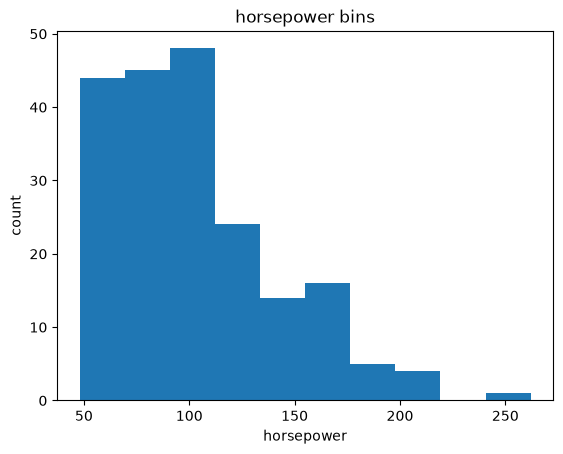

In [34]:
# %matplotlib inline
import matplotlib as plt
from matplotlib import pyplot
plt.pyplot.hist(df["horsepower"])

# set x/y labels and plot title
plt.pyplot.xlabel("horsepower")
plt.pyplot.ylabel("count")
plt.pyplot.title("horsepower bins")

<p>Nếu chúng ta muốn chia dữ liệu thành 3 nhóm có kích thước bằng nhau, chúng ta có thể sử dụng hàm <code>linspace(start_value, end_value, numbers_generated</code> của thư viện numpy</p>
<p>Chúng ta có thể set giá trị start_value=min(df["horsepower"]): giá trị thấp nhất của cột horsepower trong bộ dữ liệu mình có</p>
<p>Chúng ta có thể set giá trị end_value=max(df["horsepower"]): giá trị cao nhất của cột horsepower trong bộ dữ liệu mình có</p>
<p>Bởi vì chúng ta muốn chia dữ liệu thành 3 nhóm, chúng ta có thể set numbers_generated=4</p>

Sau đây là một ví dụ:

In [35]:
bins = np.linspace(min(df["horsepower"]), max(df["horsepower"]), 4)
bins

array([ 48.        , 119.33333333, 190.66666667, 262.        ])

Đặt tên cho các nhóm dữ liệu


In [36]:
group_names = ['Low', 'Medium', 'High']

Chúng ta có thể áp dụng hàm `cut` để chia dữ liệu cột `df['horsepower']` về các nhóm đã được chỉ định:

In [37]:
df['horsepower-binned'] = pd.cut(df['horsepower'], bins, labels=group_names, include_lowest=True )
df[['horsepower','horsepower-binned']].head(20)

,horsepower,horsepower-binned
0,111,Low
1,111,Low
2,154,Medium
3,102,Low
4,115,Low
5,110,Low
6,110,Low
7,110,Low
8,140,Medium
9,101,Low


Xem số lượng xe cho từng nhóm dữ liệu:

In [38]:
df["horsepower-binned"].value_counts()

horsepower-binned
Low       153
Medium     43
High        5
Name: count, dtype: int64

<h3>Vẽ biểu đồ phân phối dữ liệu cho từng nhóm dữ liệu được khởi tạo
</h3>

Thông thường, biểu đồ histogram thường được sử dụng để trực quan phân bố dữ liệu của các nhóm dữ liệu!

Text(0.5, 1.0, 'horsepower bins')

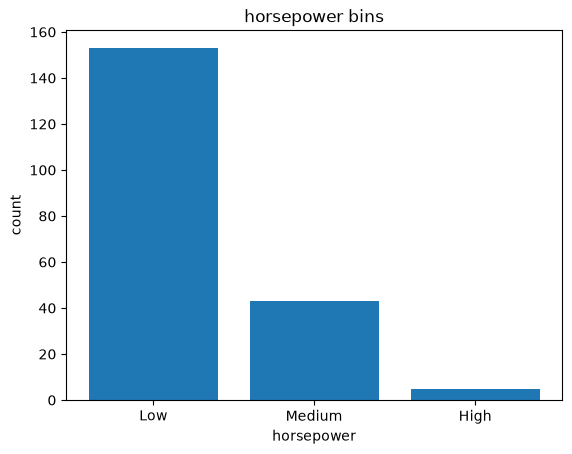

In [39]:
# %matplotlib inline
import matplotlib as plt
from matplotlib import pyplot
pyplot.bar(group_names, df["horsepower-binned"].value_counts())

# set x/y labels and plot title
plt.pyplot.xlabel("horsepower")
plt.pyplot.ylabel("count")
plt.pyplot.title("horsepower bins")

<h2 id="indicator">Biến chỉ báo (indicator variable) - hay còn được gọi là biến giả (Dummy variable)</h2>
<b>Biến chỉ báo là gì?</b>
<p>
    Biến chỉ báo (hoặc biến giả) là một biến số được sử dụng để gắn nhãn cho các danh mục, chúng được gọi là 'dummy' (hình nộm) vì bản thân các con số không có ý nghĩa.
</p>

<b>Tại sao chúng ta lại cần sử dụng biến chỉ báo?</b>

<p>
    Giúp chúng ta có thể sử dụng các biến định tính cho các bài toán phân tích hồi quy.
</p>
<b>Ví dụ: </b>
<p>
    Cột "fuel-type" có 2 giá trị chính: "gas" hay "diesel". Các mô hình hồi quy không thể hiểu các chữ cái từ cột fuel-type, mà chúng chỉ hiểu các cột có giá trị dưới dạng số. 
    Dễ sử dụng cột fuel-type (cột định tính) trong các bài toán phân tích hồi quy, chúng ta có thể biến đổi cột fuel-type thành biến chỉ báo hay biến giả!
</p>

<p>
    Chúng ta có thể sử dụng hàm 'get_dummies' trong thư viện pandas để biết cột fuel-type thành các cột dữ liệu dạng số và có thể sử dụng được trong các mô hình machine learning nói chung và mô hình hồi quy nói riêng! 
</p>


In [40]:
df.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-L/100km', 'price', 'city-L/100km', 'horsepower-binned'],
      dtype='object')

In [41]:
df["fuel-type"]

0         gas
1         gas
2         gas
3         gas
4         gas
        ...  
196       gas
197       gas
198       gas
199    diesel
200       gas
Name: fuel-type, Length: 201, dtype: object

Lấy thông tin các biến chỉ báo và gán nó thành một dataframe có tên là: "dummy_variable_1" 


In [42]:
dummy_variable_1 = pd.get_dummies(df["fuel-type"], dtype=int)
dummy_variable_1.head()

,diesel,gas
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


Đổi tên cột để phân biệt loại nhiên liệu:

In [43]:
dummy_variable_1.rename(columns={'gas':'fuel-type-gas', 'diesel':'fuel-type-diesel'}, inplace=True)
dummy_variable_1.head()

,fuel-type-diesel,fuel-type-gas
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


Join bảng dummy_variable_1 vào dataframe gốc df để được một dataframe mới, đồng thời drop cột fuel-type

In [44]:
# merge data frame "df" and "dummy_variable_1" 
df = pd.concat([df, dummy_variable_1], axis=1)

# xoá cột "fuel-type" từ dataframe "df"
df.drop("fuel-type", axis = 1, inplace=True)


<h1> Bài tập 4: </h1>

Tham khảo ví dụ trên, Tạo biến chỉ báo cho cột  `aspiration`

In [45]:
dummy_variable_2 = pd.get_dummies(df["aspiration"], dtype=int)
dummy_variable_2.rename(columns={"std":"aspiration-std", "turbo": "aspiration-turbo"}, inplace=True)
dummy_variable_2.head()

,aspiration-std,aspiration-turbo
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


<h1> Bài tập 5: </h1>

Join bảng biến chỉ bảo vào dataframe gốc df để được một dataframe mới, đồng thời drop cột aspiration

In [46]:
df = pd.concat([df, dummy_variable_2], axis=1)
df.drop("aspiration", axis=1, inplace=True)
df.head()

,symboling,normalized-losses,make,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,horsepower-binned,fuel-type-diesel,fuel-type-gas,aspiration-std,aspiration-turbo
0,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,0.890278,...,5000.0,21,8.703704,13495.0,11.190476,Low,0,1,1,0
1,3,122,alfa-romero,two,convertible,rwd,front,88.6,0.811148,0.890278,...,5000.0,21,8.703704,16500.0,11.190476,Low,0,1,1,0
2,1,122,alfa-romero,two,hatchback,rwd,front,94.5,0.822681,0.909722,...,5000.0,19,9.038462,16500.0,12.368421,Medium,0,1,1,0
3,2,164,audi,four,sedan,fwd,front,99.8,0.848630,0.919444,...,5500.0,24,7.833333,13950.0,9.791667,Low,0,1,1,0
4,2,164,audi,four,sedan,4wd,front,99.4,0.848630,0.922222,...,5500.0,18,10.681818,17450.0,13.055556,Low,0,1,1,0


Xuất file kết quả thành một file excel với tên clean_df.csv

In [47]:
df.to_csv("clean_df.csv", index=False)